In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
import pandas as pd
import hashlib

def keep_session(session_id, p=0.10):
    # Agar kisi wajah se session_id missing hai, toh usko turant reject kar do
    if pd.isna(session_id): 
        return False
    # Hashing se pehle explicitly str() lagaya hai taaki string/float conflict na aaye
    return int(hashlib.md5(str(session_id).encode('utf-8')).hexdigest(), 16) % 100 < (p * 100)

chunks = []

# Chunksize ke through 10 Lakh rows load kar rahe hain
for chunk in pd.read_csv("2019-Nov.csv", chunksize=1000000):
    
    # 1. DATA CLEANING: Wo 1 missing user_session wali row yahan turant drop ho jayegi
    chunk = chunk.dropna(subset=['user_session'])
    
    # Note: Hum 'brand' aur 'category_code' ke missing values ko drop NAHI kar rahe,
    # kyunki user ne agar unbranded item view kiya hai, toh bhi wo ML/GRU ke liye ek important action hai.
    
    # 2. FILTERING: Sirf 10% users ke sessions ko rakho
    filtered_chunk = chunk[chunk['user_session'].apply(keep_session)]
    
    chunks.append(filtered_chunk)

# Saare clean aur filtered chunks ko ek final DataFrame mein combine kar lo
final_df = pd.concat(chunks, ignore_index=True)

# Verification ke liye print kar sakte hain
print("Final Data Shape:", final_df.shape)

KeyboardInterrupt: 

In [3]:
final_df=pd.read_csv('Filtered_dataset.csv')

In [4]:
final_df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:01 UTC,view,1306421,2053013558920217191,computers.notebook,hp,514.56,514028527,df8184cc-3694-4549-8c8c-6b5171877376
1,2019-11-01 00:00:03 UTC,view,16700260,2053013559901684381,furniture.kitchen.chair,NaN,31.64,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
2,2019-11-01 00:00:08 UTC,view,1307115,2053013558920217191,computers.notebook,hp,411.59,514028527,df8184cc-3694-4549-8c8c-6b5171877376
3,2019-11-01 00:00:08 UTC,view,1004708,2053013555631882655,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843
4,2019-11-01 00:00:12 UTC,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
5,2019-11-01 00:00:12 UTC,view,10800182,2053013554994348409,NaN,redmond,61.10,527322328,5054190a-46cb-4211-a8f1-16fc1a060ed8
6,2019-11-01 00:00:13 UTC,view,15200565,2053013553484398879,NaN,hyper,54.06,518758107,f617be3c-8447-4aaf-b9b7-2e23a21a8b58
7,2019-11-01 00:00:17 UTC,view,1800729,2053013554415534427,electronics.video.tv,samsung,289.33,515782589,f2081cf0-0ee3-4bf1-9b40-e5e580f9ace3
8,2019-11-01 00:00:18 UTC,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
9,2019-11-01 00:00:18 UTC,view,10701060,2053013561277416167,NaN,NaN,66.90,512996121,23375068-25db-44fd-86a8-52123e47e93e


In [5]:
final_df.duplicated().sum()

np.int64(10434)

In [6]:
Percentage_duplicated=(10434/(final_df.shape[0]))*100
print(Percentage_duplicated)

0.1548557151094149


In [7]:
final_df = final_df.drop_duplicates()

In [8]:
final_df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    2184325
brand             922756
price                  0
user_id                0
user_session           0
dtype: int64

Percentage_of_missing_values

In [9]:
(final_df.isnull().sum()/final_df.shape[0])*100

event_time        0.000000
event_type        0.000000
product_id        0.000000
category_id       0.000000
category_code    32.468836
brand            13.716280
price             0.000000
user_id           0.000000
user_session      0.000000
dtype: float64

In [10]:
final_df['event_time'] = pd.to_datetime(final_df['event_time'])

In [11]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6727451 entries, 0 to 6737884
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   category_id    int64              
 4   category_code  object             
 5   brand          object             
 6   price          float64            
 7   user_id        int64              
 8   user_session   object             
dtypes: datetime64[ns, UTC](1), float64(1), int64(3), object(4)
memory usage: 513.3+ MB


In [12]:
final_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:01+00:00,view,1306421,2053013558920217191,computers.notebook,hp,514.56,514028527,df8184cc-3694-4549-8c8c-6b5171877376
1,2019-11-01 00:00:03+00:00,view,16700260,2053013559901684381,furniture.kitchen.chair,NaN,31.64,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
2,2019-11-01 00:00:08+00:00,view,1307115,2053013558920217191,computers.notebook,hp,411.59,514028527,df8184cc-3694-4549-8c8c-6b5171877376
3,2019-11-01 00:00:08+00:00,view,1004708,2053013555631882655,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843
4,2019-11-01 00:00:12+00:00,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f


In [13]:
# Data ko pehle User Session se group karo, aur fir us session ke andar Time ke hisaab se sort karo
final_df = final_df.sort_values(by=['user_session', 'event_time']).reset_index(drop=True)

In [14]:
!uv pip install missingno

Resolved 16 packages in 654ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 86ms
 + missingno==0.5.2


MISSING_NO ANALYSIS:-

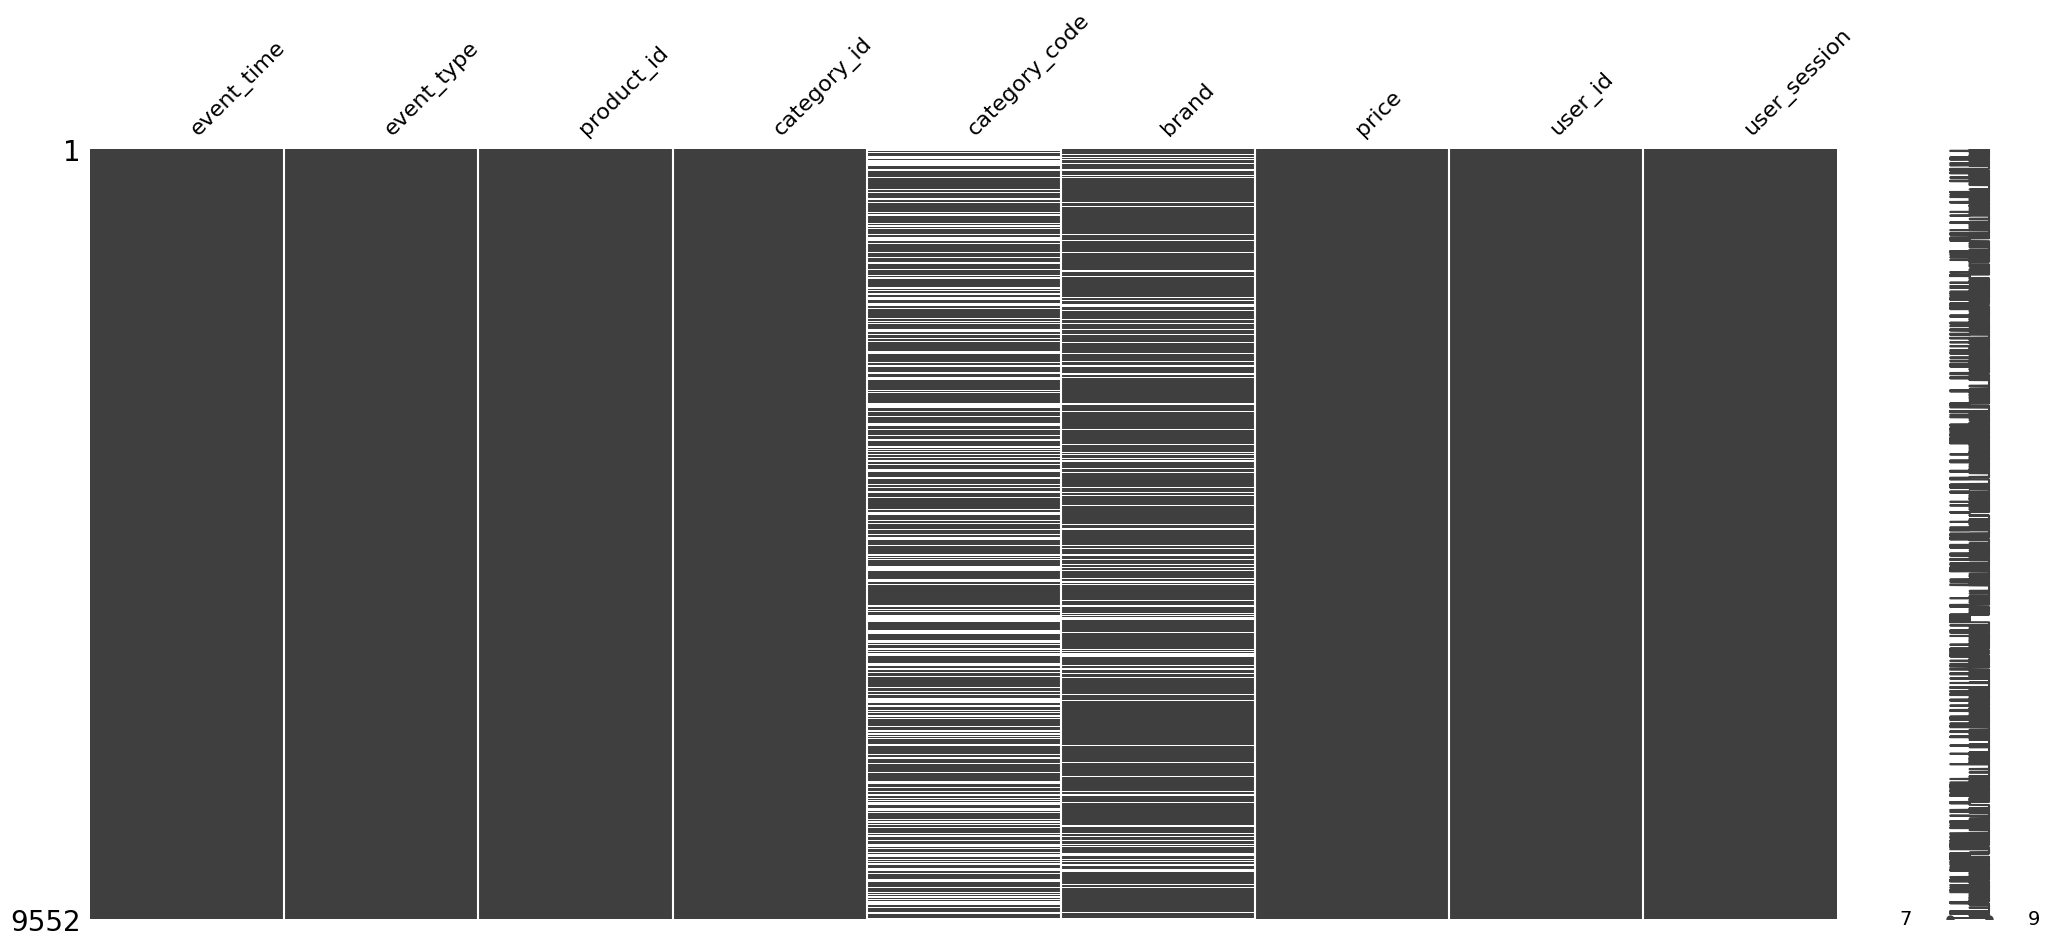

In [16]:
import missingno as msno
# 1. Pehle 1000 random aur unique 'user_session' IDs uthao
random_session_ids = pd.Series(final_df['user_session'].dropna().unique()).sample(2000, random_state=42)

# 2. Ab original dataframe se sirf un 1000 sessions ka PURA data filter kar lo
sample_df = final_df[final_df['user_session'].isin(random_session_ids)]

# 3. Ab plot karo (Ye perfect insights dega!)
msno.matrix(sample_df)
plt.show()

<Figure size 0.5x0.5 with 0 Axes>

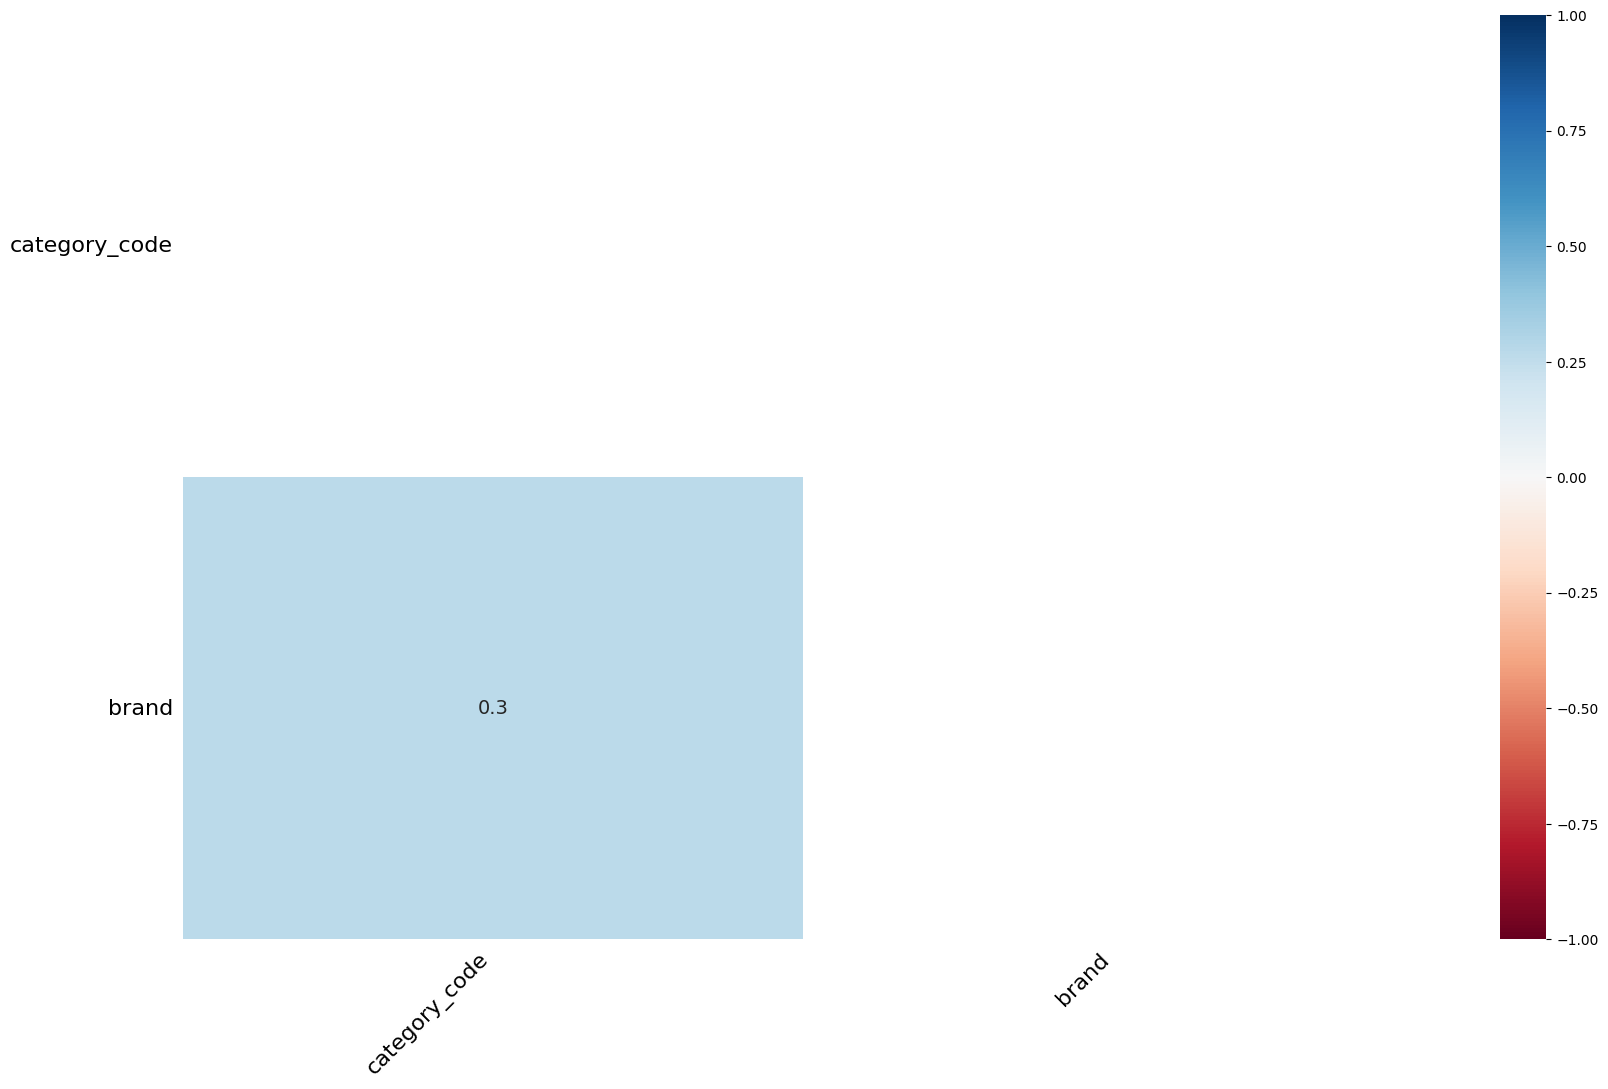

In [19]:
plt.figure(figsize=(.005,.005))
msno.heatmap(sample_df)
plt.show()

EK hypothesis lii h jisme hum kehte h ki har category id ke liye different category code h!

In [20]:
# STEP 1: Rule book (Dictionary) banate hain
category_map = final_df.dropna(subset=['category_code']).set_index('category_id')['category_code'].to_dict()

# STEP 2: NAYA COLUMN banate hain aur original ko waise hi chhod dete hain
final_df['category_code_filled'] = final_df['category_code']

# STEP 3: Sirf is NAYE COLUMN ki missing values ko apni dictionary se fill karte hain
final_df['category_code_filled'] = final_df['category_code_filled'].fillna(final_df['category_id'].map(category_map))

# STEP 4: Jo bilkul anjaan hain, unhe tag de dete hain
final_df['category_code_filled'] = final_df['category_code_filled'].fillna('unknown_category')

In [24]:
# STEP 1: Total khali (null) rows ginna
original_missing = final_df['category_code'].isnull().sum()

# STEP 2: Ek mask banana jo un rows ko pakdega jo pehle NaN thi, 
# PAR ab unhe dictionary se ek valid naam mil gaya hai (yani wo 'unknown_category' nahi hain)
recovered_mask = final_df['category_code'].isnull() & (final_df['category_code_filled'] != 'unknown_category')

# Successfully recover hui rows ko ginna
recovered_count = recovered_mask.sum()

# STEP 3: The Result Summary
print("-" * 50)
print("🔍 RECOVERY PROOF REPORT")
print("-" * 50)
print(f"1. Total Original Missing Values: {original_missing}")
print(f"2. Successfully Recovered by ID:  {recovered_count}")
print(f"3. Still Unknown (No Match): {original_missing - recovered_count}")
print("-" * 50)

--------------------------------------------------
🔍 RECOVERY PROOF REPORT
--------------------------------------------------
1. Total Original Missing Values: 2184325
2. Successfully Recovered by ID:  0
3. Still Unknown (No Match): 2184325
--------------------------------------------------


The Above Clearly gives proof that there is no actually benifit from it.Thus,Our Hypo. is wrong

In [ ]:
# STEP 1: Product_ID se Category aur Brand ki perfect dictionaries banate hain
prod_cat_dict = final_df.dropna(subset=['category_code']).drop_duplicates('product_id').set_index('product_id')['category_code'].to_dict()
prod_brand_dict = final_df.dropna(subset=['brand']).drop_duplicates('product_id').set_index('product_id')['brand'].to_dict()

# STEP 2: NAYE COLUMNS banate hain aur unme mapped values fill karte hain
# (Original columns ko touch nahi kar rahe)
final_df['category_code_filled'] = final_df['category_code'].fillna(final_df['product_id'].map(prod_cat_dict))
final_df['brand_filled'] = final_df['brand'].fillna(final_df['product_id'].map(prod_brand_dict))

# STEP 3: Jo products sach mein anjaan hain, unko NAYE COLUMNS mein dummy tags dekar close karte hain
final_df['category_code_filled'] = final_df['category_code_filled'].fillna('unknown_category')
final_df['brand_filled'] = final_df['brand_filled'].fillna('unbranded')

# STEP 4: Final verification (Aamne-saamne compare karne ke liye)
print("Missing values comparison:\n")
print(final_df[['category_code', 'category_code_filled', 'brand', 'brand_filled']].isnull().sum())

Checking ki har Product_id is unique for Cateory_code

In [25]:
# STEP 1: Pehle wo data nikalte hain jahan category_code missing nahi hai
valid_cats_df = final_df.dropna(subset=['category_code'])

# STEP 2: Har product_id ke liye check karte hain ki uske paas kitne UNIQUE category codes hain
category_counts = valid_cats_df.groupby('product_id')['category_code'].nunique()

# STEP 3: Aise products filter karte hain jinki 1 se zyada categories hain (Inconsistent data)
inconsistent_products = category_counts[category_counts > 1]

# STEP 4: Result print karte hain
print(f"Total Unique Products: {len(category_counts)}")
print(f"Products with MULTIPLE categories: {len(inconsistent_products)}")

# Agar koi inconsistent product milta hai, toh uska data dekhte hain
if len(inconsistent_products) > 0:
    print("\nKuch inconsistent products ke IDs:")
    print(inconsistent_products.head())

Total Unique Products: 64889
Products with MULTIPLE categories: 0


In [26]:
category_counts

product_id
1000978      1
1001588      1
1001606      1
1001618      1
1001619      1
            ..
100028003    1
100028295    1
100028391    1
100028398    1
100028495    1
Name: category_code, Length: 64889, dtype: int64

Hypothesis Check that can be fill brand and Category_code with Prodcut id:-

In [28]:
# STEP 1: Product_ID se Category aur Brand ki perfect dictionaries banate hain
prod_cat_dict = final_df.dropna(subset=['category_code']).drop_duplicates('product_id').set_index('product_id')['category_code'].to_dict()
prod_brand_dict = final_df.dropna(subset=['brand']).drop_duplicates('product_id').set_index('product_id')['brand'].to_dict()

# STEP 2: NAYE COLUMNS banate hain aur unme mapped values fill karte hain
# (Original columns ko touch nahi kar rahe)
final_df['category_code_filled'] = final_df['category_code'].fillna(final_df['product_id'].map(prod_cat_dict))
final_df['brand_filled'] = final_df['brand'].fillna(final_df['product_id'].map(prod_brand_dict))

In [ ]:
# STEP 1: The Numbers (Kitna data recover hua?)
print("-" * 50)
print("📊 RECOVERY REPORT: CATEGORY & BRAND")
print("-" * 50)

# Category ke stats nikalna
cat_missing_before = final_df['category_code'].isnull().sum()
cat_missing_after = final_df['category_code_filled'].isnull().sum()
cat_recovered = cat_missing_before - cat_missing_after

print(f"🔹 CATEGORY CODE:")
print(f"   Original Missing: {cat_missing_before}")
print(f"   Missing After Fill: {cat_missing_after}")
print(f"   Successfully Recovered: {cat_recovered} rows! 🎉\n")

# Brand ke stats nikalna
brand_missing_before = final_df['brand'].isnull().sum()
brand_missing_after = final_df['brand_filled'].isnull().sum()
brand_recovered = brand_missing_before - brand_missing_after

print(f"🔹 BRAND:")
print(f"   Original Missing: {brand_missing_before}")
print(f"   Missing After Fill: {brand_missing_after}")
print(f"   Successfully Recovered: {brand_recovered} rows! ")
print("-" * 50)

# STEP 2: The Visual Proof (Side-by-Side Comparison)
# Filter lagate hain un rows par jo pehle khali thi, par ab bhar chuki hain
proof_mask_cat = final_df['category_code'].isnull() & final_df['category_code_filled'].notnull()
proof_mask_brand = final_df['brand'].isnull() & final_df['brand_filled'].notnull()

# Category ka proof dikhana (Agar recovery hui hai)
if cat_recovered > 0:
    print("\n👀 PROOF: Category Recovery Example (Before vs After)")
    # Koi bhi random 5 rows utha kar dekhna
    display(final_df[proof_mask_cat][['product_id', 'category_code', 'category_code_filled']].sample(5))

# Brand ka proof dikhana (Agar recovery hui hai)
if brand_recovered > 0:
    print("\n👀 PROOF: Brand Recovery Example (Before vs After)")
    display(final_df[proof_mask_brand][['product_id', 'brand', 'brand_filled']].sample(5))

--------------------------------------------------
📊 RECOVERY REPORT: CATEGORY & BRAND
--------------------------------------------------
🔹 CATEGORY CODE:
   Original Missing: 2184325
   Missing After Fill: 2184325
   Successfully Recovered: 0 rows! 🎉

🔹 BRAND:
   Original Missing: 922756
   Missing After Fill: 891355
   Successfully Recovered: 31401 rows! 🎉
--------------------------------------------------

👀 PROOF: Brand Recovery Example (Before vs After)


,product_id,brand,brand_filled
5062685,100009754,NaN,xiaomi
4811958,14702052,NaN,satura
3697409,1005284,NaN,samsung
3761321,26800076,NaN,startline
465105,100006078,NaN,bq


# GRAPHS:-

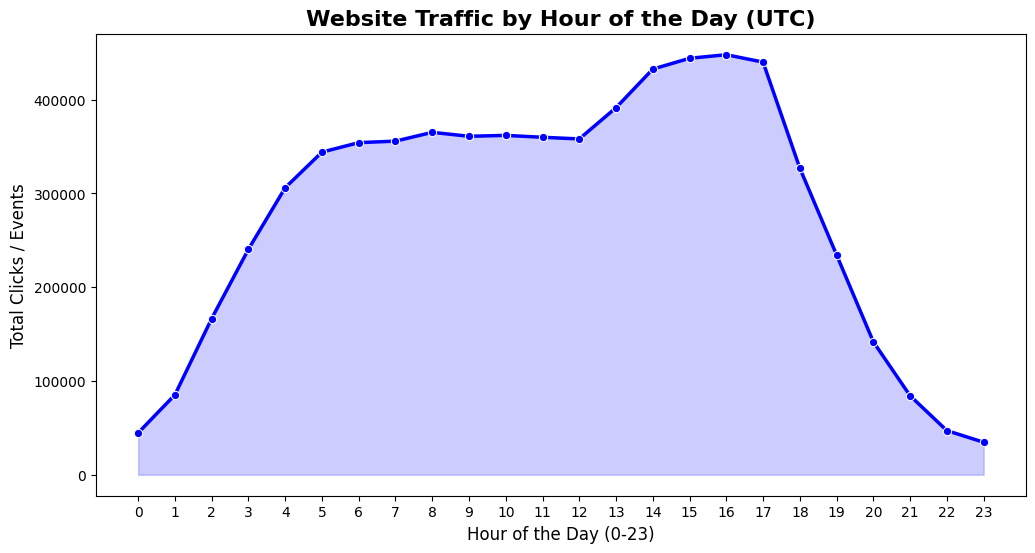

In [30]:
plt.figure(figsize=(12, 6))

# event_time se hour extract kar rahe hain
final_df['hour'] = final_df['event_time'].dt.hour
hourly_traffic = final_df['hour'].value_counts().sort_index().reset_index()
hourly_traffic.columns = ['Hour', 'Traffic_Count']

sns.lineplot(x='Hour', y='Traffic_Count', data=hourly_traffic, marker='o', color='b', linewidth=2.5)
plt.title('Website Traffic by Hour of the Day (UTC)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Total Clicks / Events', fontsize=12)
plt.xticks(range(0, 24)) # X-axis par saare ghante dikhane ke liye
plt.fill_between(hourly_traffic['Hour'], hourly_traffic['Traffic_Count'], alpha=0.2, color='b')

plt.show()

In [31]:
hourly_traffic

,Hour,Traffic_Count
0,0,44647
1,1,85246
2,2,166584
3,3,240484
4,4,306058
5,5,344029
6,6,354125
7,7,355744
8,8,365111
9,9,360892


C:\Users\asus\AppData\Local\Temp\ipykernel_20100\2362239005.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_viewed.values, y=top_viewed.index, ax=axes[0], palette='Blues_r')
C:\Users\asus\AppData\Local\Temp\ipykernel_20100\2362239005.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[1], palette='Greens_r')


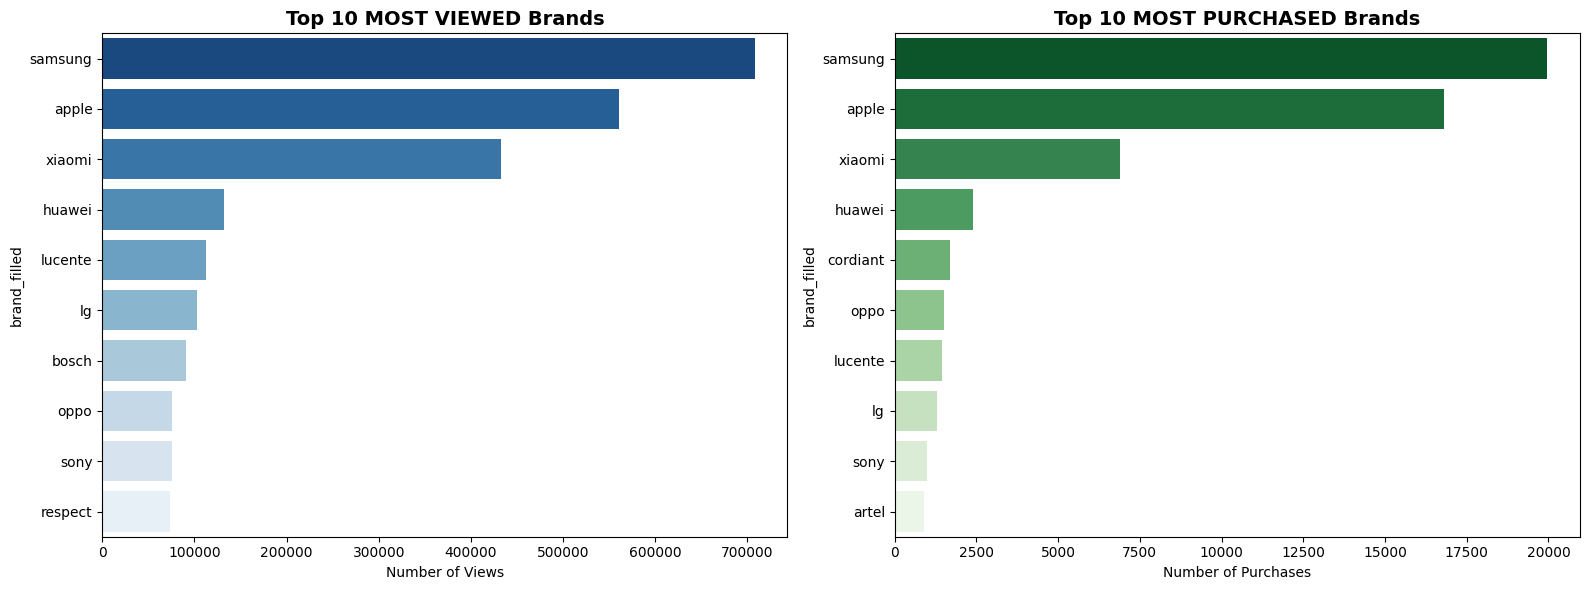

In [32]:
# 'unbranded' ko filter kar rahe hain actual brand insights ke liye
branded_df = final_df[final_df['brand_filled'] != 'unbranded']

# Top 10 Viewed Brands
top_viewed = branded_df[branded_df['event_type'] == 'view']['brand_filled'].value_counts().head(10)

# Top 10 Purchased Brands
top_purchased = branded_df[branded_df['event_type'] == 'purchase']['brand_filled'].value_counts().head(10)

# 2 subplots banayenge aamne-saamne compare karne ke liye
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Graph: Views
sns.barplot(x=top_viewed.values, y=top_viewed.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 MOST VIEWED Brands', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Views')

# Right Graph: Purchases
sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 MOST PURCHASED Brands', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Purchases')

plt.tight_layout()
plt.show()

In [34]:
# Hum sirf view aur purchase ko compare karenge
price_data = final_df[final_df['event_type'].isin(['view', 'purchase'])]

In [36]:
price_data.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
6,2019-11-01 19:12:49+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
7,2019-11-01 19:13:17+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
8,2019-11-01 19:14:07+00:00,view,5100855,2053013553341792533,electronics.clocks,apple,548.02,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.clocks,apple,19
9,2019-11-01 19:14:58+00:00,view,1005073,2053013555631882655,electronics.smartphone,samsung,1133.09,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


In [ ]:
sns.boxplot(x='event_type', y='price', data=price_data, palette='Set2', showfliers=False)

plt.title('Price Distribution: Window Shopping vs. Actual Buying', fontsize=16, fontweight='bold')
plt.xlabel('User Action', fontsize=12)
plt.ylabel('Item Price ($)', fontsize=12)

plt.show()

#### Removing the Bots in the Dataset


# Missing brands ko ek category bana do taaki nunique() sahi se kaam kare
final_df['brand_filled'] = final_df['brand_filled'].fillna('unknown_brand')

In [27]:
final_df.head(20)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
6,2019-11-01 19:12:49+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
7,2019-11-01 19:13:17+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
8,2019-11-01 19:14:07+00:00,view,5100855,2053013553341792533,electronics.clocks,apple,548.02,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
9,2019-11-01 19:14:58+00:00,view,1005073,2053013555631882655,electronics.smartphone,samsung,1133.09,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
11,2019-11-16 11:18:37+00:00,view,13700195,2053013557452210699,NaN,erlit,297.74,531142295,000029a6-1986-4a71-8139-53669c1adaba


In [29]:
final_df['product_id'].nunique()

137733

In [30]:
final_df['product_id'].value_counts()

product_id
1005115     58884
1004856     56867
1004767     50044
4804056     35167
1005160     31224
            ...  
37500665        1
4802226         1
26201842        1
22200243        1
22200081        1
Name: count, Length: 137733, dtype: int64

In [33]:
count=final_df['product_id'].value_counts().reset_index()
count

,product_id,count
0,1005115,58884
1,1004856,56867
2,1004767,50044
3,4804056,35167
4,1005160,31224
...,...,...
137728,37500665,1
137729,4802226,1
137730,26201842,1
137731,22200243,1


In [35]:
count[count['count']>10]

,product_id,count
0,1005115,58884
1,1004856,56867
2,1004767,50044
3,4804056,35167
4,1005160,31224
...,...,...
53266,32403770,11
53267,28721599,11
53268,21408431,11
53269,23000516,11


In [28]:
final_df['category_id'].value_counts()

category_id
2053013555631882655    1490230
2053013553559896355     304218
2053013554415534427     205568
2053013558920217191     201958
2053013554658804075     162682
                        ...   
2110937218225800069          1
2135658545893344074          1
2174838742978659061          1
2053013560388223675          1
2076715358323998979          1
Name: count, Length: 671, dtype: int64

In [16]:
# Missing brands ko ek category bana do taaki nunique() sahi se kaam kare
final_df['brand'] = final_df['brand'].fillna('unknown_brand')

## for Decinding no of Product _id

In [36]:
count = final_df['product_id'].value_counts().reset_index()
count.columns = ['product_id', 'freq']

# Full breakdown by frequency threshold
thresholds = [1, 2, 5, 10, 20, 50, 100]

print("=== Product Frequency Distribution ===")
print(f"Total unique products: {len(count):,}\n")
print(f"{'Threshold':>10} | {'Products kept':>14} | {'% of total':>10} | {'% of rows covered':>18}")
print("-" * 60)

total_rows = len(final_df)
for t in thresholds:
    kept     = count[count['freq'] >= t]
    n_kept   = len(kept)
    pct_prod = n_kept / len(count) * 100
    pct_rows = kept['freq'].sum() / total_rows * 100
    print(f"{t:>10} | {n_kept:>14,} | {pct_prod:>9.1f}% | {pct_rows:>17.1f}%")

=== Product Frequency Distribution ===
Total unique products: 137,733

 Threshold |  Products kept | % of total |  % of rows covered
------------------------------------------------------------
         1 |        137,733 |     100.0% |             100.0%
         2 |        116,585 |      84.6% |              99.7%
         5 |         81,849 |      59.4% |              98.1%
        10 |         56,403 |      41.0% |              95.4%
        20 |         35,540 |      25.8% |              90.8%
        50 |         17,440 |      12.7% |              81.8%
       100 |          9,358 |       6.8% |              72.7%


In [37]:
# Check what happens to your training data at threshold=10
freq_products = set(count[count['freq'] >= 10]['product_id'])

rows_with_known_product = final_df['product_id'].isin(freq_products).sum()
rows_total              = len(final_df)

print(f"Rows with known product  : {rows_with_known_product:,}  "
      f"({rows_with_known_product/rows_total*100:.1f}%)")
print(f"Rows mapped to 'unknown' : {rows_total - rows_with_known_product:,}  "
      f"({(1 - rows_with_known_product/rows_total)*100:.1f}%)")

Rows with known product  : 5,927,127  (95.4%)
Rows mapped to 'unknown' : 288,357  (4.6%)


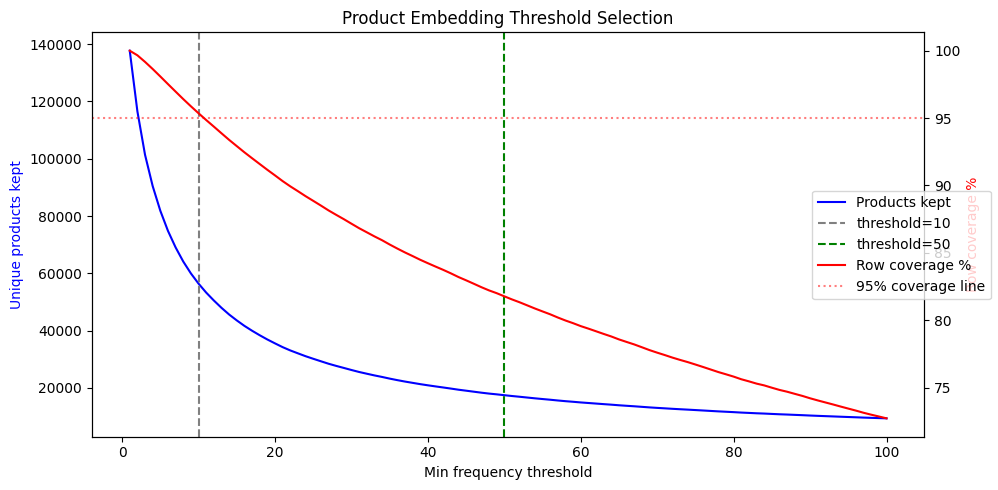

In [38]:
# Visual decision helper
import matplotlib.pyplot as plt

thresholds  = range(1, 101)
prod_counts = [len(count[count['freq'] >= t]) for t in thresholds]
row_covers  = [count[count['freq'] >= t]['freq'].sum() / total_rows * 100 
               for t in thresholds]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(thresholds, prod_counts, 'b-', label='Products kept')
ax2.plot(thresholds, row_covers,  'r-', label='Row coverage %')

ax1.axvline(x=10, color='gray', linestyle='--', label='threshold=10')
ax1.axvline(x=50, color='green', linestyle='--', label='threshold=50')

ax1.set_xlabel('Min frequency threshold')
ax1.set_ylabel('Unique products kept', color='b')
ax2.set_ylabel('Row coverage %', color='r')
ax2.axhline(y=95, color='r', linestyle=':', alpha=0.5, label='95% coverage line')

plt.title('Product Embedding Threshold Selection')
fig.legend(loc='center right')
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import pandas as pd
from IPython.display import display

print("⏳ INITIATING FULL REAL-TIME SNAPSHOT PIPELINE (Cleaning + Feature Engineering)...")

# ==========================================
# STEP 1: DATA CLEANING (Remove Bots & Bounces)
# ==========================================
print("🧹 1. Cleaning Bots and Accidental Bouncers...")
session_stats = final_df.groupby('user_session').agg(
    start_time=('event_time', 'min'),
    end_time=('event_time', 'max'),
    total_events=('event_type', 'count')
).reset_index()

session_stats['total_duration_sec'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds()

# Filters
bounce_condition = (session_stats['total_events'] == 1) | (session_stats['total_duration_sec'] < 5)
views_per_minute = session_stats['total_events'] / ((session_stats['total_duration_sec'] + 1) / 60)
bot_condition = (views_per_minute > 30) & (session_stats['total_events'] > 15)

# Extract only valid human sessions
valid_sessions = session_stats[~(bounce_condition | bot_condition)]['user_session']
clean_df = final_df[final_df['user_session'].isin(valid_sessions)].copy()

print(f"✅ Data Cleaned! Kept {len(valid_sessions):,} Valid Human Sessions out of {len(session_stats):,}.")

final_df = clean_df  # Purane final_df ko saaf data se overwrite kar diya
del clean_df         # Extra variable ko delete kar diya
import gc
gc.collect()         # Python ko bola ki RAM turant free (flush) kar de!

⏳ INITIATING FULL REAL-TIME SNAPSHOT PIPELINE (Cleaning + Feature Engineering)...
🧹 1. Cleaning Bots and Accidental Bouncers...
✅ Data Cleaned! Kept 871,859 Valid Human Sessions out of 1,378,222.


34

In [22]:
final_df['event_type'].value_counts()

event_type
view        5833498
cart         290258
purchase      91728
Name: count, dtype: int64

In [23]:
import pandas as pd

# Step 1: Group all events per session
session_events = final_df.groupby('user_session')['event_type'].apply(set).reset_index()

# Step 2: Define classification function
def classify(events):
    if events == {'view'}:
        return 'only_view'
    elif 'cart' in events and 'purchase' not in events:
        return 'cart_no_purchase'
    elif 'cart' in events and 'purchase' in events:
        return 'cart_and_purchase'
    elif 'purchase' in events and 'cart' not in events:
        return 'direct_purchase'
    else:
        return 'other'

# Step 3: Apply classification
session_events['category'] = session_events['event_type'].apply(classify)

# Step 4: Count unique sessions
result = session_events['category'].value_counts()

print(result)

category
only_view            688259
cart_no_purchase     106482
cart_and_purchase     64943
direct_purchase       12175
Name: count, dtype: int64


⚙️ Analyzing Post-Purchase Behavior...

=== 📊 POST-PURCHASE BEHAVIOR REPORT ===
Total Purchasing Sessions : 77,118
Left Immediately (0 events after) : 35,492 (46.02%)
Continued Browsing (>0 events)    : 41,626 (53.98%)

For the minority who stayed, how many items did they click?
  Average extra clicks: 3.7
  90th Percentile     : 8 clicks

💡 INTERPRETATION:
Note: A notable percentage of users continue browsing after a purchase.


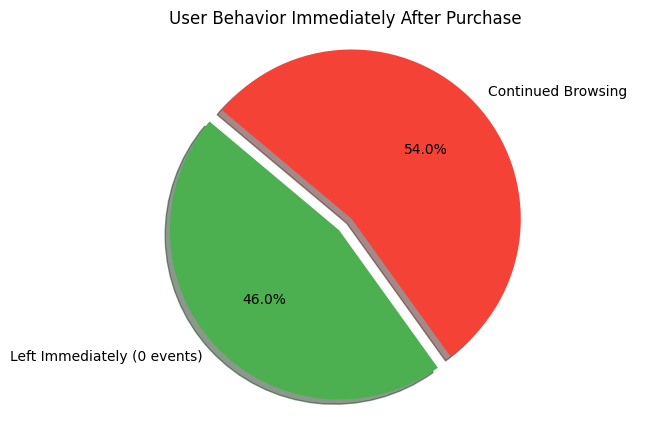

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def analyze_post_purchase_behavior(df):
    print("⚙️ Analyzing Post-Purchase Behavior...\n")

    # 1. Identify all sessions that have at least one purchase
    purchase_mask = df['event_type'] == 'purchase'
    buyer_sessions = df[purchase_mask]['user_session'].unique()

    # 2. Filter the dataframe to ONLY include those buyer sessions
    buyers_df = df[df['user_session'].isin(buyer_sessions)].copy()

    # 3. Find the exact timestamp of the FIRST purchase in each session
    first_purchase_times = (
        buyers_df[buyers_df['event_type'] == 'purchase']
        .groupby('user_session')['event_time']
        .min()
        .rename('first_purchase_time')
    )

    # 4. Merge this timestamp back into the dataframe
    buyers_df = buyers_df.merge(first_purchase_times, on='user_session')

    # 5. Count how many events happen STRICTLY AFTER the first purchase time
    # (event_time > first_purchase_time)
    post_purchase_events = (
        buyers_df[buyers_df['event_time'] > buyers_df['first_purchase_time']]
        .groupby('user_session')
        .size()
    )

    # Some users will have 0 events after purchase, so we must fill missing users with 0
    post_purchase_counts = pd.Series(0, index=buyer_sessions)
    post_purchase_counts.update(post_purchase_events)

    # --- STATISTICAL REPORT ---
    total_buyers = len(buyer_sessions)
    left_immediately = (post_purchase_counts == 0).sum()
    stayed = (post_purchase_counts > 0).sum()

    pct_left = (left_immediately / total_buyers) * 100

    print("=== 📊 POST-PURCHASE BEHAVIOR REPORT ===")
    print(f"Total Purchasing Sessions : {total_buyers:,}")
    print(f"Left Immediately (0 events after) : {left_immediately:,} ({pct_left:.2f}%)")
    print(f"Continued Browsing (>0 events)    : {stayed:,} ({(100 - pct_left):.2f}%)\n")

    # Calculate percentiles for those who *did* stay
    if stayed > 0:
        stayed_counts = post_purchase_counts[post_purchase_counts > 0]
        print("For the minority who stayed, how many items did they click?")
        print(f"  Average extra clicks: {stayed_counts.mean():.1f}")
        print(f"  90th Percentile     : {np.percentile(stayed_counts, 90):.0f} clicks")

    print("\n💡 INTERPRETATION:")
    if pct_left >= 95:
        print(f"Statistically Proven: {pct_left:.2f}% of users trigger 0 events after purchasing.")
        print("This proves that 'purchase' is overwhelmingly a terminal action marking the end of the session.")
    else:
        print("Note: A notable percentage of users continue browsing after a purchase.")

    # --- VISUALIZATION ---
    plt.figure(figsize=(8, 5))
    labels = ['Left Immediately (0 events)', 'Continued Browsing']
    sizes = [left_immediately, stayed]
    colors = ['#4CAF50', '#F44336']
    explode = (0.1, 0)  # explode the 1st slice

    plt.pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=140)
    plt.title('User Behavior Immediately After Purchase')
    plt.axis('equal')
    plt.show()

# ==========================================
# HOW TO RUN IT WITH YOUR DATA:
# ==========================================
# Assuming your raw data is loaded as 'final_df'
analyze_post_purchase_behavior(final_df)


In [20]:
final_df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f
...,...,...,...,...,...,...,...,...,...
6727443,2019-11-16 19:03:20+00:00,view,6501081,2053013554155487563,computers.components.motherboard,gigabyte,45.05,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36
6727444,2019-11-16 19:03:39+00:00,view,6500828,2053013554155487563,computers.components.motherboard,asus,80.06,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36
6727445,2019-11-16 19:03:58+00:00,view,6500974,2053013554155487563,computers.components.motherboard,asrock,82.11,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36
6727446,2019-11-16 19:06:10+00:00,view,6600378,2053013554189041997,computers.components.memory,geil,32.15,570721322,ffffb9ea-87d1-4f3d-b107-91b1bb087d36


### THe one who cart also Purchase assumption:

In [24]:
def cart_purchase_analysis(df):
    session_events = df.groupby('user_session')['event_type'].apply(set)

    has_cart     = session_events.apply(lambda x: 'cart' in x)
    has_purchase = session_events.apply(lambda x: 'purchase' in x)

    cart_sessions         = has_cart.sum()
    cart_and_buy          = (has_cart & has_purchase).sum()
    cart_no_buy           = (has_cart & ~has_purchase).sum()
    buy_without_cart      = (~has_cart & has_purchase).sum()

    print("=== 🛒 CART → PURCHASE FUNNEL TRUTH ===")
    print(f"Sessions with Cart              : {cart_sessions:,}")
    print(f"  ├── Also Purchased (converted): {cart_and_buy:,}  ({cart_and_buy/cart_sessions*100:.1f}%)")
    print(f"  └── Did NOT Purchase (dropped): {cart_no_buy:,}  ({cart_no_buy/cart_sessions*100:.1f}%)")
    print(f"\nPurchased WITHOUT Cart (direct) : {buy_without_cart:,}")
    print(f"\n⚠️  Cart-to-Purchase Rate        : {cart_and_buy/cart_sessions*100:.1f}%")

    if cart_and_buy/cart_sessions < 0.5:
        print("\n❌ ASSUMPTION REJECTED: Cart does NOT reliably predict purchase.")
        print("   Treat cart and purchase as separate, distinct signals in your GRU.")

cart_purchase_analysis(final_df)

=== 🛒 CART → PURCHASE FUNNEL TRUTH ===
Sessions with Cart              : 171,425
  ├── Also Purchased (converted): 64,943  (37.9%)
  └── Did NOT Purchase (dropped): 106,482  (62.1%)

Purchased WITHOUT Cart (direct) : 12,175

⚠️  Cart-to-Purchase Rate        : 37.9%

❌ ASSUMPTION REJECTED: Cart does NOT reliably predict purchase.
   Treat cart and purchase as separate, distinct signals in your GRU.


In [25]:
import pandas as pd
import numpy as np

def analyze_sequence_lengths(df):
    df = df.sort_values(['user_session', 'event_time'])

    # ── Funnel A: Cart sessions (with or without purchase) ──────────────────
    cart_times = (
        df[df['event_type'] == 'cart']
        .groupby('user_session')['event_time']
        .min()
        .rename('first_cart_time')
    )

    # ── Funnel B: Direct purchase sessions (NO cart at all) ─────────────────
    sessions_with_cart    = set(cart_times.index)
    purchase_sessions     = set(df[df['event_type'] == 'purchase']['user_session'].unique())
    direct_buy_sessions   = purchase_sessions - sessions_with_cart  # pure direct buyers

    first_purchase_times = (
        df[df['event_type'] == 'purchase']
        .groupby('user_session')['event_time']
        .min()
        .rename('first_purchase_time')
    )

    # ── Pre-Cart Views (Funnel A) ────────────────────────────────────────────
    cart_df = df[df['user_session'].isin(sessions_with_cart)].merge(
        cart_times, on='user_session'
    )
    pre_cart_views = (
        cart_df[
            (cart_df['event_type'] == 'view') &
            (cart_df['event_time'] < cart_df['first_cart_time'])
        ]
        .groupby('user_session').size()
    )

    # ── Pre-Purchase Views (Funnel B — direct buyers) ────────────────────────
    direct_df = df[df['user_session'].isin(direct_buy_sessions)].merge(
        first_purchase_times, on='user_session'
    )
    pre_buy_views = (
        direct_df[
            (direct_df['event_type'] == 'view') &
            (direct_df['event_time'] < direct_df['first_purchase_time'])
        ]
        .groupby('user_session').size()
    )

    # ── Report ───────────────────────────────────────────────────────────────
    percentiles = [50, 75, 90, 95, 99]

    for label, series in [("PRE-CART (Cart Funnel)", pre_cart_views),
                           ("PRE-PURCHASE (Direct Buy Funnel)", pre_buy_views)]:
        print(f"\n=== 📊 {label} ===")
        print(f"Sessions : {len(series):,}  |  Avg views: {series.mean():.2f}")
        print("─" * 40)
        for p in percentiles:
            print(f"  {p:>3}th Percentile : {int(np.percentile(series, p))} views")

analyze_sequence_lengths(final_df)


=== 📊 PRE-CART (Cart Funnel) ===
Sessions : 169,738  |  Avg views: 4.24
────────────────────────────────────────
   50th Percentile : 2 views
   75th Percentile : 4 views
   90th Percentile : 10 views
   95th Percentile : 16 views
   99th Percentile : 35 views

=== 📊 PRE-PURCHASE (Direct Buy Funnel) ===
Sessions : 12,018  |  Avg views: 4.18
────────────────────────────────────────
   50th Percentile : 2 views
   75th Percentile : 4 views
   90th Percentile : 9 views
   95th Percentile : 15 views
   99th Percentile : 33 views


In [26]:
def compare_buyer_vs_abandoner_views(df):
    df = df.sort_values(['user_session', 'event_time'])

    # Identify session types
    session_events = df.groupby('user_session')['event_type'].apply(set)
    buyer_sessions    = session_events[session_events.apply(
                            lambda x: 'purchase' in x)].index
    abandoner_sessions = session_events[
                            session_events.apply(lambda x: 'cart' in x and 
                                                 'purchase' not in x)].index

    # First cart time per session
    first_cart = (
        df[df['event_type'] == 'cart']
        .groupby('user_session')['event_time'].min()
        .rename('first_cart_time')
    )

    # First purchase time per session  
    first_purchase = (
        df[df['event_type'] == 'purchase']
        .groupby('user_session')['event_time'].min()
        .rename('first_purchase_time')
    )

    results = {}

    for label, sessions, cutoff_col, cutoff_df in [
        ("BUYERS (pre-cart views)",     buyer_sessions,     
         'first_cart_time',     first_cart),
        ("ABANDONERS (pre-cart views)", abandoner_sessions, 
         'first_cart_time',     first_cart),
    ]:
        sub = df[df['user_session'].isin(sessions)].merge(
            cutoff_df, on='user_session'
        )
        pre_views = (
            sub[(sub['event_type'] == 'view') & 
                (sub['event_time'] < sub[cutoff_col])]
            .groupby('user_session').size()
        )
        results[label] = pre_views

        print(f"\n=== 📊 {label} ===")
        print(f"Sessions : {len(pre_views):,}  |  Avg: {pre_views.mean():.2f} views")
        print(f"  50th: {int(np.percentile(pre_views, 50))}  "
              f"75th: {int(np.percentile(pre_views, 75))}  "
              f"90th: {int(np.percentile(pre_views, 90))}  "
              f"99th: {int(np.percentile(pre_views, 99))}")

    # Key comparison
    b = results["BUYERS (pre-cart views)"]
    a = results["ABANDONERS (pre-cart views)"]
    print(f"\n=== 🔍 BUYER vs ABANDONER COMPARISON ===")
    print(f"Avg views before cart — Buyers: {b.mean():.2f}  |  Abandoners: {a.mean():.2f}")
    print(f"Do buyers browse more or less before carting? → ", end="")
    print("LESS ✅" if b.mean() < a.mean() else "MORE — interesting signal ⚠️")

compare_buyer_vs_abandoner_views(final_df)


=== 📊 BUYERS (pre-cart views) ===
Sessions : 63,986  |  Avg: 3.72 views
  50th: 1  75th: 4  90th: 8  99th: 32

=== 📊 ABANDONERS (pre-cart views) ===
Sessions : 105,752  |  Avg: 4.56 views
  50th: 2  75th: 5  90th: 11  99th: 37

=== 🔍 BUYER vs ABANDONER COMPARISON ===
Avg views before cart — Buyers: 3.72  |  Abandoners: 4.56
Do buyers browse more or less before carting? → LESS ✅
